# SAM vs COCO Ground Truth Evaluation

This notebook evaluates Segment Anything Model (SAM) predictions against COCO ground truth masks.

## Evaluation Metrics:
- **IoU (Intersection over Union)**: Overlap between predicted and ground truth masks
- **Dice Coefficient**: Similarity measure for segmentation
- **Precision & Recall**: Per-pixel classification accuracy
- **Boundary F1 Score**: Edge quality metric
- **Mean metrics across dataset samples**

## 1. Install Dependencies

In [25]:
!pip install segment-anything git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib pycocotools scikit-image pandas seaborn

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-kxx_5h_s
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-kxx_5h_s
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


## 2. Import Libraries

In [26]:
import torch
import gc
import random
import numpy as np
import cv2
from google.colab import drive
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
import urllib.request
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
import os
from PIL import Image
import requests
from io import BytesIO
from skimage import measure
from scipy.ndimage import distance_transform_edt
import pandas as pd
import seaborn as sns
import json
from pathlib import Path
from pycocotools import mask as mask_utils
import pdb
from tqdm import tqdm

drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/COCO_Dataset'
# Your extracted folder path
image_dir = '/content/drive/MyDrive/sam_dataset/minibatch'
project_dir = "/content/drive/MyDrive/marl"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Download SAM Model

In [27]:
!nvidia-smi
# Choose model size: 'vit_h' (best), 'vit_l', or 'vit_b' (fastest)
model_type = "vit_b"

checkpoint_url = {
    'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth',
    'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
    'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'
}

checkpoint_path = f"sam_{model_type}.pth"

if not os.path.exists(checkpoint_path):
    print(f"Downloading {model_type} checkpoint...")
    urllib.request.urlretrieve(checkpoint_url[model_type], checkpoint_path)
    print("Download complete!")

# Initialize SAM
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
sam.to(device=device)
predictor = SamPredictor(sam)

print("SAM model loaded!")

Thu Nov 27 11:03:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             33W /   70W |    2164MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [28]:
def calculate_iou(pred_mask, gt_mask):
    """Calculate Intersection over Union."""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    if union == 0:
        return 0.0
    return intersection / union

def calculate_dice(pred_mask, gt_mask):
    """Calculate Dice coefficient."""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    total = pred_mask.sum() + gt_mask.sum()
    if total == 0:
        return 0.0
    return 2 * intersection / total

def calculate_metrics(pred_mask, gt_mask):
    """Calculate comprehensive metrics."""
    iou = calculate_iou(pred_mask, gt_mask)
    dice = calculate_dice(pred_mask, gt_mask)

    intersection = np.logical_and(pred_mask, gt_mask).sum()
    pred_area = pred_mask.sum()
    gt_area = gt_mask.sum()

    precision = intersection / pred_area if pred_area > 0 else 0
    recall = intersection / gt_area if gt_area > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'iou': iou,
        'dice': dice,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


def visualize_comparison(image, gt_mask, pred_mask, metrics, bbox, title=""):
    """Visualize ground truth vs prediction."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')

    # Image with bbox
    img_with_bbox = image.copy()
    x1, y1, x2, y2 = bbox.astype(int)
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (255, 0, 0), 3)
    axes[0, 1].imshow(img_with_bbox)
    axes[0, 1].set_title("Bounding Box (SAM Input)")
    axes[0, 1].axis('off')

    # Ground truth
    axes[0, 2].imshow(image)
    axes[0, 2].imshow(gt_mask, alpha=0.5, cmap='Greens')
    axes[0, 2].set_title("Ground Truth (SA-1B)")
    axes[0, 2].axis('off')

    # SAM prediction
    axes[1, 0].imshow(image)
    axes[1, 0].imshow(pred_mask, alpha=0.5, cmap='Blues')
    axes[1, 0].set_title("SAM Prediction")
    axes[1, 0].axis('off')

    # Overlap
    overlap = np.zeros((*gt_mask.shape, 3))
    overlap[gt_mask, 0] = 1  # GT in red
    overlap[pred_mask, 2] = 1  # Pred in blue
    overlap[np.logical_and(gt_mask, pred_mask)] = [1, 1, 0]  # Overlap in yellow

    axes[1, 1].imshow(image)
    axes[1, 1].imshow(overlap, alpha=0.5)
    axes[1, 1].set_title(f"Overlap (IoU: {metrics['iou']:.3f})")
    axes[1, 1].axis('off')

    # Metrics text
    axes[1, 2].axis('off')
    metrics_text = f"""
    {title}

    METRICS:
    IoU: {metrics['iou']:.4f}
    Dice: {metrics['dice']:.4f}
    Precision: {metrics['precision']:.4f}
    Recall: {metrics['recall']:.4f}
    F1: {metrics['f1']:.4f}

    SAM Score: {metrics['sam_score']:.4f}

    GT Quality:
    Pred IoU: {metrics['gt_predicted_iou']:.4f}
    Stability: {metrics['gt_stability_score']:.4f}
    Area: {metrics['gt_area']:.0f} px
    """
    axes[1, 2].text(0.1, 0.5, metrics_text, fontsize=12,
                    verticalalignment='center', family='monospace')

    plt.tight_layout()
    plt.show()

Starting SAM evaluation on SA-1B data...
Found 21 JSON files in /content/drive/MyDrive/sam_dataset/minibatch

Image 1/21: Copy of sa_223750.json

  Mask 1/74:
    IoU: 0.7733 | Dice: 0.8721 | F1: 0.8721 | SAM Score: 0.8644

  Mask 2/74:
    IoU: 0.8704 | Dice: 0.9307 | F1: 0.9307 | SAM Score: 0.8288

  Mask 3/74:
    IoU: 0.9130 | Dice: 0.9545 | F1: 0.9545 | SAM Score: 0.9034

  Mask 4/74:
    IoU: 0.9108 | Dice: 0.9533 | F1: 0.9533 | SAM Score: 0.8596

  Mask 5/74:
    IoU: 0.9714 | Dice: 0.9855 | F1: 0.9855 | SAM Score: 0.9563

  Mask 6/74:
    IoU: 0.9448 | Dice: 0.9716 | F1: 0.9716 | SAM Score: 0.9128

  Mask 7/74:
    IoU: 0.8862 | Dice: 0.9396 | F1: 0.9396 | SAM Score: 0.8750

  Mask 8/74:
    IoU: 0.9426 | Dice: 0.9704 | F1: 0.9704 | SAM Score: 0.9472

  Mask 9/74:
    IoU: 0.9275 | Dice: 0.9624 | F1: 0.9624 | SAM Score: 0.9003

  Mask 10/74:
    IoU: 0.8431 | Dice: 0.9149 | F1: 0.9149 | SAM Score: 0.8555

  Mask 11/74:
    IoU: 0.9194 | Dice: 0.9580 | F1: 0.9580 | SAM Score: 0.

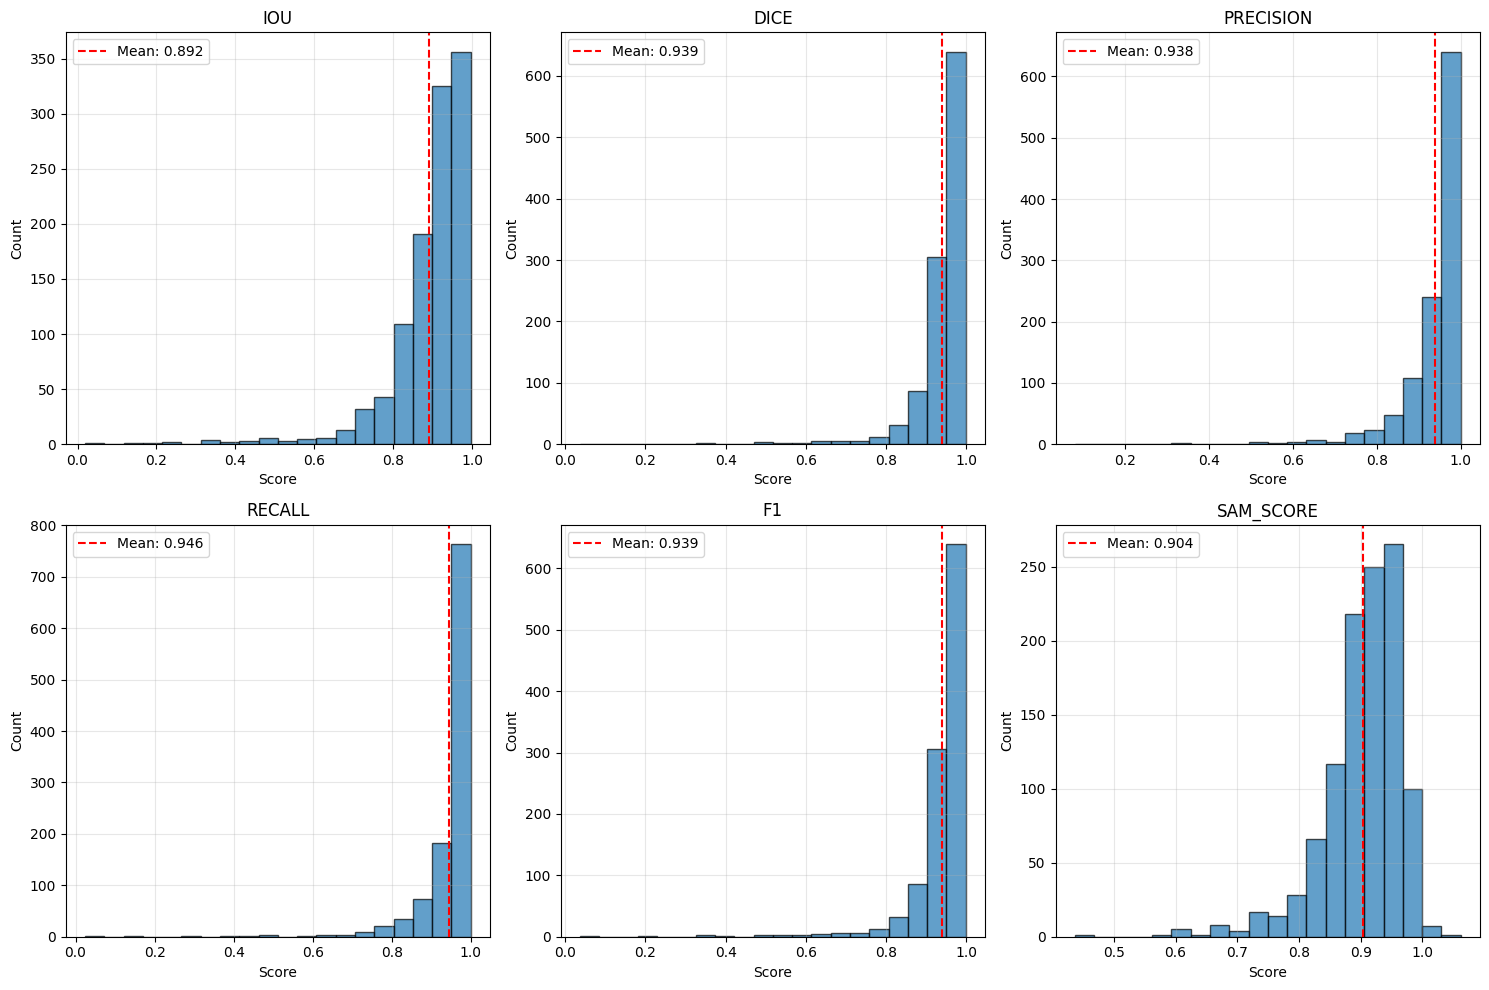

In [29]:
def decode_sa1b_mask(annotation):
    """Decode SA-1B RLE mask to binary mask."""
    segmentation = annotation['segmentation']
    if isinstance(segmentation, dict):
        mask = mask_utils.decode(segmentation)
    else:
        raise ValueError(f"Unexpected segmentation format: {type(segmentation)}")
    return mask.astype(bool)


def load_sa1b_image_and_annotations(json_path):
    """Load image and annotations from SA-1B format."""
    json_path = Path(json_path)

    # Load JSON
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Load image
    img_path = json_path.with_suffix('.jpg')
    if not img_path.exists():
        raise FileNotFoundError(f"Image not found: {img_path}")

    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image, data

def evaluate_sam_on_annotation(image, annotation, predictor):
    """Evaluate SAM on a single annotation using its bounding box as prompt."""

    # Get ground truth mask
    gt_mask = decode_sa1b_mask(annotation)

    # Get bounding box from annotation
    bbox = annotation['bbox']  # [x, y, width, height]
    input_box = np.array([bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]])

    # SAM prediction
    predictor.set_image(image)

    with torch.no_grad():
        masks, scores, logits = predictor.predict(
            point_coords=None,
            point_labels=None,
            box=input_box[None, :],
            multimask_output=False,
        )

    pred_mask = masks[0]
    sam_score = scores[0]

    # Calculate metrics
    metrics = calculate_metrics(pred_mask, gt_mask)
    metrics['sam_score'] = sam_score
    metrics['gt_predicted_iou'] = annotation.get('predicted_iou', 0)
    metrics['gt_stability_score'] = annotation.get('stability_score', 0)
    metrics['gt_area'] = annotation.get('area', gt_mask.sum())

    predictor.reset_image()

    return pred_mask, gt_mask, metrics, input_box

def evaluate_sam_on_folder(extracted_dir, predictor, num_images='max'):
    """
    Evaluate SAM on random images from extracted folder.

    Args:
        extracted_dir: Path to extracted SA-1B folder
        predictor: SAM predictor instance
        num_images: Number of images to evaluate
    """

    extracted_dir = Path(extracted_dir)
    dataset = pd.DataFrame(columns=["imgage_file", "json_file", "annotation", "IoU", "Dice", "Precision", "Recall", "F1 socre"])
    # Find all JSON files
    json_files = list(extracted_dir.glob("**/*.json"))
    json_files.sort()

    if len(json_files) == 0:

        print("No JSON files found! Check your path.")
        return

    else:

        print(f"Found {len(json_files)} JSON files in {extracted_dir}")

    # Randomly sample images
    # random.shuffle(json_files)

    all_metrics = []
    images_evaluated = 0

    for json_path in json_files:

      if num_images != 'max':

        if images_evaluated >= num_images:
            break

        try:
            # Load image and annotations
            image, data = load_sa1b_image_and_annotations(json_path)

            # pdb.set_trace()
            # Filter high-quality annotations
            annotations = [ann for ann in data['annotations']]

            print(f"\n{'='*80}")
            print(f"Image {images_evaluated + 1}/{len(json_files)}: {json_path.name}")
            # print(f"Image size: {data['image']['width']}x{data['image']['height']}")
            print(f"{'='*80}")

            # Evaluate on multiple masks from this image
            num_to_eval = len(annotations)
            # selected_anns = random.sample(annotations, num_to_eval)

            for i, ann in enumerate(annotations):
                print(f"\n  Mask {i+1}/{num_to_eval}:")

                # Evaluate
                pred_mask, gt_mask, metrics, bbox = evaluate_sam_on_annotation(image, ann, predictor)

                dataset[len(dataset)] = [str(json_path.name) + ".jpg", str(json_path.name) + ".json"
                , ann, metrics['iou'], metrics['dice'], metrics['precision'], metrics['recall'],
                                         metrics['f1']]

                # Store metrics
                all_metrics.append(metrics)

                # Print metrics
                print(f"    IoU: {metrics['iou']:.4f} | Dice: {metrics['dice']:.4f} | "
                      f"F1: {metrics['f1']:.4f} | SAM Score: {metrics['sam_score']:.4f}")

                # Visualize
                # visualize_comparison(image, gt_mask, pred_mask, metrics, bbox, title=f"{json_path.name} - Mask {i+1}/{num_to_eval}")

                # Memory cleanup
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            images_evaluated += 1

        except Exception as e:
            print(f"Error processing {json_path.name}: {e}")
            continue

    # Summary statistics
    if all_metrics:
        print(f"\n{'='*80}")
        print("SUMMARY STATISTICS")
        print(f"{'='*80}")
        print(f"Total masks evaluated: {len(all_metrics)}")
        print(f"Images evaluated: {images_evaluated}")
        print(f"\nAverage Metrics:")

        for key in ['iou', 'dice', 'precision', 'recall', 'f1', 'sam_score']:
            values = [m[key] for m in all_metrics]
            print(f"  {key.upper():15s}: {np.mean(values):.4f} ± {np.std(values):.4f} "
                  f"(min: {np.min(values):.4f}, max: {np.max(values):.4f})")

        print(f"{'='*80}")

        # Plot distribution
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()

        for i, key in enumerate(['iou', 'dice', 'precision', 'recall', 'f1', 'sam_score']):
            values = [m[key] for m in all_metrics]
            axes[i].hist(values, bins=20, edgecolor='black', alpha=0.7)
            axes[i].axvline(np.mean(values), color='red', linestyle='--',
                          label=f'Mean: {np.mean(values):.3f}')
            axes[i].set_title(key.upper())
            axes[i].set_xlabel('Score')
            axes[i].set_ylabel('Count')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    dataset.to_csv(os.path.join(project_dir, "sam_images_metrics.csv"), index=False)
    return all_metrics

# Run evaluation
print("Starting SAM evaluation on SA-1B data...")

image_dir = '/content/drive/MyDrive/sam_dataset/minibatch'

# Make sure predictor is initialized
# predictor = ... (your SAM predictor)

metrics = evaluate_sam_on_folder(
    extracted_dir=image_dir,
    predictor=predictor,
    num_images=10
)